In [246]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [247]:
from pathlib import Path

import numpy as np
import pandas as pd
import forestplot as fplt
from scipy import stats

import phd_project.scripts.metaregression_analysis as mra
from phd_project.config import config

cfg = config.load_config()

In [248]:
# Number of bootstrap replications. One record sample is drawn per replicate and
# reused at every structure - see 1.1.
K_SAMPLES = 1000

# Storey counts to bootstrap. Only the 3s group IDAs are complete; append 5 once the
# 5s runs finish - nothing else needs to change.
N_STOREYS = [3]

# The IM the fragilities are expressed in (selects the collapse-IML table).
IM_TAG = "AvgSA_03"

BOOTSTRAP_PTH = cfg["proc_data"]["bootstrapping"]
# SAMPLES_CSV = BOOTSTRAP_PTH / "femap695_bootstrapped_indices.csv"

# # IDA arm: per-record collapse capacities (nb 053) and the group fragility summary,
# # which also carries each group's member sites.
# _iml_stem = Path(cfg["proc_data"]["wp1_groups_femap695_collapse_imls"])
# COLLAPSE_IML_CSV = _iml_stem.with_name(f"{_iml_stem.stem}_{IM_TAG}.csv")
# GROUP_FC_SUMMARY = cfg["proc_data"]["wp1_groups_femap695_fc_summary"]

# # MSA arm: per-record collapse flags at each stripe (nb 061) and the group MSA fits.
# _flag_stem = Path(cfg["proc_data"]["wp1_groups_msa_femap695_collapse_flags"])
# COLLAPSE_FLAGS_CSV = _flag_stem.with_name(f"{_flag_stem.stem}_{IM_TAG}.csv")
# GROUP_MSA_FC_SUMMARY = cfg["proc_data"]["wp1_groups_msa_femap695_fc_summary"]

# # Site-specific MSA arm: one fragility JSON per structure (nb 060). There is no summary
# # CSV for this arm, so those files are also the only source of its published fits.
# SITE_FC_ROOT = cfg["proc_data"]["wp1_sites_fragility_curves"]
# SITES = list(range(60))
# SITE_MSA_N_RECORDS = 30    # GCIM selects 30 records at every stripe (nb 017/050)

## 1.0 Load Bootstrap results

In [249]:
# load the estimates from the actual analysis
msa_ss_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["site_msa"])["site_msa"]
msa_fx_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["msa_femap695"])["msa_femap695"]
ida_fx_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["ida_femap695"])["ida_femap695"]
mgr_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["msa_femap695"], scope="by_group")["msa_femap695"]
igr_ests = mra.load_estimates(BOOTSTRAP_PTH, IM_TAG, arms=["ida_femap695"], scope="by_group")["ida_femap695"]

# load the theta and beta bootstrap replicates
msa_ss = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "site_msa", ("theta", "beta"), 3, IM_TAG, "by_site",
        k_samples=K_SAMPLES)

msa_fx = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "msa_femap695", ("theta", "beta"), 3, IM_TAG, "by_site",
        k_samples=K_SAMPLES)

ida_fx = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "ida_femap695", ("theta", "beta"), 3, IM_TAG, "by_site",
        k_samples=K_SAMPLES)

msa_gr = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "msa_femap695", ("theta", "beta"), 3, IM_TAG, "by_group",
        k_samples=K_SAMPLES)

ida_gr = mra.load_saved_bootstrap(
        BOOTSTRAP_PTH, "ida_femap695", ("theta", "beta"), 3, IM_TAG, "by_group",
        k_samples=K_SAMPLES)

In [250]:
# reformat dfs so they are easier to use and concatenate 
theta_mss = mra.reformat_bootstrap_df(msa_ss["theta"], 3)
beta_mss = mra.reformat_bootstrap_df(msa_ss["beta"], 3)

theta_mfx = mra.reformat_bootstrap_df(msa_fx["theta"], 3)
beta_mfx = mra.reformat_bootstrap_df(msa_fx["beta"], 3)

theta_ifx = mra.reformat_bootstrap_df(ida_fx["theta"], 3)
beta_ifx = mra.reformat_bootstrap_df(ida_fx["beta"], 3)

theta_mgr = msa_gr["theta"].T
beta_mgr = msa_gr["beta"].T

theta_igr = ida_gr["theta"].T
beta_igr = ida_gr["beta"].T

# replicates structure
theta_mss.head(10)

,k,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
site,n_storeys,,,,,,,,,,,,,,,,,,,,,
0,3,0.437320,0.437920,0.434298,0.423745,0.425448,0.429009,0.436425,0.437448,0.423511,0.448272,...,0.434873,0.427541,0.441857,0.412037,0.435235,0.418758,0.400610,0.416909,0.418747,0.420903
1,3,0.423989,0.423399,0.420239,0.402992,0.412252,0.402269,0.428895,0.425398,0.414200,0.417432,...,0.414050,0.447545,0.410483,0.425725,0.431586,0.416355,0.418266,0.420837,0.407557,0.413464
2,3,0.405579,0.427637,0.421194,0.418542,0.424649,0.423321,0.414745,0.417457,0.420123,0.404937,...,0.402338,0.406293,0.412690,0.392561,0.434150,0.417456,0.400352,0.417438,0.407040,0.436185
3,3,0.431446,0.439096,0.435578,0.449154,0.458519,0.426788,0.448205,0.456840,0.432013,0.453017,...,0.459534,0.434542,0.455045,0.435074,0.425694,0.462307,0.468455,0.442727,0.438160,0.449664
4,3,0.418134,0.424342,0.426765,0.446361,0.408268,0.410417,0.424946,0.411021,0.445851,0.420562,...,0.403239,0.430364,0.436180,0.418149,0.410323,0.417122,0.419203,0.438451,0.418424,0.412008
5,3,0.391677,0.398042,0.381798,0.408121,0.375234,0.397436,0.395881,0.408225,0.399549,0.395965,...,0.408043,0.390374,0.405385,0.371983,0.383296,0.381270,0.394328,0.381590,0.385947,0.382971
6,3,0.373357,0.379764,0.398188,0.392144,0.396748,0.392854,0.386170,0.391440,0.392310,0.417657,...,0.389905,0.386163,0.395475,0.382373,0.389248,0.382213,0.374287,0.386808,0.374256,0.385246
7,3,0.458578,0.465190,0.471482,0.471110,0.450947,0.466225,0.465480,0.478886,0.454676,0.464078,...,0.459491,0.466450,0.457076,0.460580,0.457076,0.473877,0.467629,0.462620,0.468532,0.481738
8,3,0.429679,0.415109,0.428235,0.419687,0.430844,0.423031,0.438471,0.451705,0.427109,0.424420,...,0.432379,0.431308,0.442805,0.440410,0.421376,0.436995,0.441654,0.433167,0.440212,0.423973


Taking the log helps to regularlise the distributions - however it can introduce some bias

In [251]:
# setting up my variable names and converting to log space
# Theta estimates::
theta_est_mss = np.log(msa_ss_ests["theta"]) 
beta_est_mss = np.log(msa_ss_ests["beta"]) 
theta_est_mfx = np.log(msa_fx_ests["theta"]) 
beta_est_mfx = np.log(msa_fx_ests["beta"])
theta_est_ifx = np.log(ida_fx_ests["theta"]) 
beta_est_ifx = np.log(ida_fx_ests["beta"])

theta_est_mgr = np.log(mgr_ests["theta"].T)
theta_est_mgr = theta_est_mgr.set_axis([i[0] for i in mgr_ests["theta"].index])
beta_est_mgr = np.log(mgr_ests["beta"].T)
beta_est_mgr = beta_est_mgr.set_axis([i[0] for i in mgr_ests["beta"].index])
theta_est_igr = np.log(igr_ests["theta"].T)
theta_est_igr = theta_est_igr.set_axis([i[0] for i in igr_ests["theta"].index])
beta_est_igr = np.log(igr_ests["beta"].T)
beta_est_igr = beta_est_igr.set_axis([i[0] for i in igr_ests["beta"].index])

# Theta replicates::
at = np.log(theta_mss)      # theta from site-specific msa
bt = np.log(theta_mfx)      # theta from fixed-set msa
ct = np.log(theta_ifx)      # theta from fixed-set ida

bt_gr = np.log(theta_mgr)      # theta from fixed-set msa group
ct_gr = np.log(theta_igr)      # theta from fixed-set ida group

# Beta replicates::
ab = np.log(beta_mss)       # beta from site-specific msa
bb = np.log(beta_mfx)       # beta from fixed-set msa
cb = np.log(beta_ifx)       # beta from fixed-set ida

bb_gr = np.log(beta_mgr)      # beta from fixed-set msa group
cb_gr = np.log(beta_igr)      # beta from fixed-set ida group

In [271]:
theta_ifx

,k,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
site,n_storeys,,,,,,,,,,,,,,,,,,,,,
0,3,0.391423,0.398267,0.435651,0.355026,0.402683,0.372147,0.382232,0.375018,0.410481,0.413282,...,0.397550,0.395337,0.418698,0.408721,0.402171,0.377803,0.389638,0.375201,0.360957,0.418367
1,3,0.387744,0.387259,0.405338,0.372561,0.377302,0.382438,0.374232,0.375308,0.405968,0.401331,...,0.385790,0.365485,0.386940,0.389886,0.392306,0.351358,0.388164,0.384781,0.364966,0.403878
2,3,0.387744,0.387259,0.405338,0.372561,0.377302,0.382438,0.374232,0.375308,0.405968,0.401331,...,0.385790,0.365485,0.386940,0.389886,0.392306,0.351358,0.388164,0.384781,0.364966,0.403878
3,3,0.372802,0.382181,0.406024,0.353900,0.390117,0.356480,0.375937,0.362296,0.401878,0.402054,...,0.389017,0.379126,0.404464,0.393056,0.396343,0.369629,0.378649,0.362159,0.351653,0.414749
4,3,0.391423,0.398267,0.435651,0.355026,0.402683,0.372147,0.382232,0.375018,0.410481,0.413282,...,0.397550,0.395337,0.418698,0.408721,0.402171,0.377803,0.389638,0.375201,0.360957,0.418367
5,3,0.387744,0.387259,0.405338,0.372561,0.377302,0.382438,0.374232,0.375308,0.405968,0.401331,...,0.385790,0.365485,0.386940,0.389886,0.392306,0.351358,0.388164,0.384781,0.364966,0.403878
6,3,0.387744,0.387259,0.405338,0.372561,0.377302,0.382438,0.374232,0.375308,0.405968,0.401331,...,0.385790,0.365485,0.386940,0.389886,0.392306,0.351358,0.388164,0.384781,0.364966,0.403878
7,3,0.472452,0.476347,0.485744,0.448561,0.463900,0.459013,0.442006,0.479383,0.490267,0.486342,...,0.482982,0.455980,0.471751,0.467609,0.464101,0.429413,0.485080,0.467234,0.432918,0.487226
8,3,0.391423,0.398267,0.435651,0.355026,0.402683,0.372147,0.382232,0.375018,0.410481,0.413282,...,0.397550,0.395337,0.418698,0.408721,0.402171,0.377803,0.389638,0.375201,0.360957,0.418367


(25, 1000)

## 2.0 Statistical Models

### 2.1 Model A0: Basic RE Model for Difference between  MSA-SS and IDA-FX

#### 2.1.1 Without Bias Correction

In [252]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0 = at - ct    # mss - ifx     shape(n_rows, k_samples)
y0_est = theta_est_mss - theta_est_ifx      # mss - ifx direct from fragilities (n_rows, 1)
# calculate the total variance for each replicate 
# if mss and ifx are independent of each other (i.e. due to different record sets) we
# can sum them together. We can also calculate the variance directly from the bootstrap 
# samples which will automatically contain any covariance incase they aren't fully independent. 
v0_boot = y0.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [f"{site}_{ns}s" for (site, ns) in y0_est.index]

<Axes: >

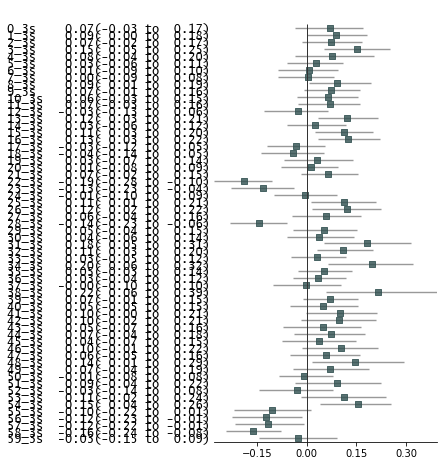

In [253]:
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est, 
                   "lb": lb, 
                   "ub": ub, 
                   "labels": labels})
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

In [254]:
# heterogeneity analysis
het_tests_A0 = mra.compute_heterogeneity_stats(v0_boot, y0_est)
print("Heterogeneity tests for the effect size (mss/ifx) in log units:")
for test, value in het_tests_A0.items():
    print(f"  {test:<5}: {value:.4f}")

Heterogeneity tests for the effect size (mss/ifx) in log units:
  Q    : 170.0722
  Q_df : 111.0722
  T_sq : 0.0048
  T    : 0.0690
  I_sq : 65.3089


In [255]:
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot, y0_est, len(y0_est))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0.columns:
    y0_col = y0[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot, y0_col, len(y0_col))[:-1])

df_A0 = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

In [256]:
# calculate the variance of the summary effect
V_m0_A0 = df_A0["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_A0 = df_A0["M_star"].quantile(q=0.025)
ub_A0 = df_A0["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred_A0 = M_star_est - stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_A0)
UL_pred_A0 = M_star_est + stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_A0)

print(f"Prediction Interval: {np.exp(LL_pred_A0):.4f} - {np.exp(UL_pred_A0):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_A0):.4f} - {np.exp(ub_A0):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/ifx) in real units")

Prediction Interval: 0.8966 - 1.2058    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 0.9874 - 1.0978    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 1.0398    <-- the mean effect size (mss/ifx) in real units


In [257]:
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_A0), "SE_model", SE_star_est)

SE_boot 0.02675837700643691 SE_model 0.011121116903402839


### 2.2 Model A1: Basic RE Model between MSA-SS and MSA-FX

Analyses the difference between the fixed record set and the site-specific one

In [258]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0 = at - bt    # mss - mfx     shape(n_rows, k_samples)
y0_est = theta_est_mss - theta_est_mfx      # mss - mfx direct from fragilities (n_rows, 1)
# calculate the total variance directly from the bootstrap samples which will 
# automatically contain any covariance incase they aren't fully independent. 
v0_boot = y0.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [f"{site}_{ns}s" for (site, ns) in y0_est.index]

<Axes: >

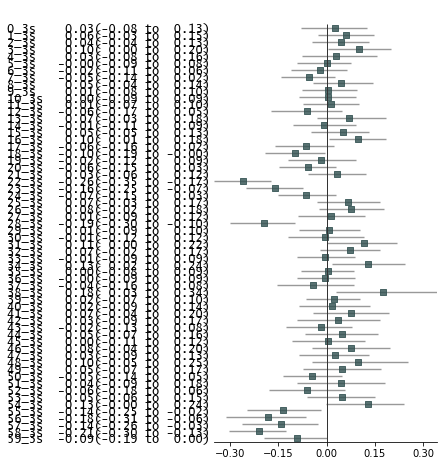

In [259]:
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est, 
                   "lb": lb, 
                   "ub": ub, 
                   "labels": labels})
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

In [260]:
# heterogeneity analysis
het_tests_A1 = mra.compute_heterogeneity_stats(v0_boot, y0_est)
print("Heterogeneity tests for the effect size (mss/mfx) in log units:")
for test, value in het_tests_A1.items():
    print(f"  {test:<5}: {value:.4f}")

Heterogeneity tests for the effect size (mss/mfx) in log units:
  Q    : 166.7216
  Q_df : 107.7216
  T_sq : 0.0048
  T    : 0.0694
  I_sq : 64.6117


In [261]:
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot, y0_est, len(y0_est))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0.columns:
    y0_col = y0[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot, y0_col, len(y0_col))[:-1])

df_A1 = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

In [262]:
# calculate the variance of the summary effect
V_m0_A1 = df_A1["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_A1 = df_A1["M_star"].quantile(q=0.025)
ub_A1 = df_A1["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred_A1 = M_star_est - stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_A1)
UL_pred_A1 = M_star_est + stats.t.ppf(0.975, len(y0_est)-2) * np.sqrt(T_sq + V_m0_A1)

print(f"Prediction Interval: {np.exp(LL_pred_A1):.4f} - {np.exp(UL_pred_A1):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_A1):.4f} - {np.exp(ub_A1):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/mfx) in real units")

Prediction Interval: 0.8568 - 1.1567    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 0.9416 - 1.0508    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 0.9955    <-- the mean effect size (mss/mfx) in real units


In [263]:
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_A1), "SE_model", SE_star_est)

SE_boot 0.028314598920852654 SE_model 0.011248006533820883


### 2.3 Model A2: Basic RE Model between MSA-FX and IDA-FX

Analyses the difference between the MSA and the IDA procedure for the same record set

In [264]:
# 1. Calculate the effect size for each study
# get the difference in log units (same as the ratio in real units)
y0_gr = bt_gr - ct_gr    # mfx - ifx     shape(n_rows, k_samples)
y0_est_gr = theta_est_mgr - theta_est_igr      # mss - mfx direct from fragilities (n_rows, 1)
# calculate the total variance directly from the bootstrap samples which will 
# automatically contain any covariance incase they aren't fully independent. 
v0_boot_gr = y0_gr.var(axis=1)    # variance along a row -> reduce the columns 

# get the upper and lower confidence interval for the forest plot.
# just use percentile samples as they are transformation respecting
lb = y0_gr.quantile(q=0.025, axis=1, numeric_only=True)
ub = y0_gr.quantile(q=0.975, axis=1, numeric_only=True)

# set the labels for each row
labels = [g for g in y0_est_gr.index]

<Axes: >

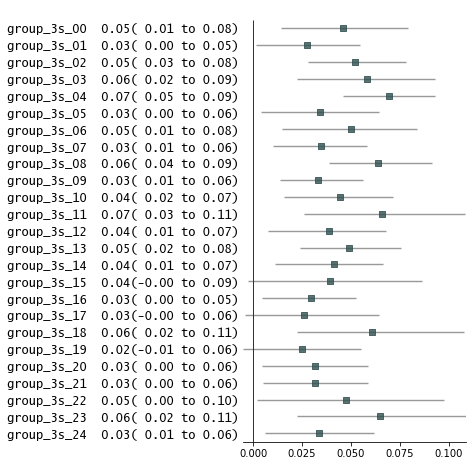

In [265]:
# 2. create a forest plot
df = pd.DataFrame({"effect": y0_est_gr.to_numpy(), 
                   "lb": lb.to_numpy(), 
                   "ub": ub.to_numpy(), 
                   "labels": labels
                   })
fplt.forestplot(df, estimate="effect", ll="lb", hl="ub", varlabel="labels")

In [266]:
# heterogeneity analysis
het_tests_A2 = mra.compute_heterogeneity_stats(v0_boot_gr, y0_est_gr)
print("Heterogeneity tests for the effect size (mss/mfx) in log units:")
for test, value in het_tests_A2.items():
    print(f"  {test:<5}: {value:.4f}")

Heterogeneity tests for the effect size (mss/mfx) in log units:
  Q    : 19.8817
  Q_df : -4.1183
  T_sq : 0.0000
  T    : 0.0000
  I_sq : 0.0000


Q_df is less than 0 - which indicates that the bewteen site variation is less than the within-site variation.
T_sq and I_sq go to zero and the random effects model collapses to a fixed-effects model. This basically what we would expect. The structure itself (at least within the CBF group) has not effect on the ratio of the median collapse capacity obtained from MSA-FX and IDA-FX.

In [267]:
# Fit the model to the estimates to get the effect size.
M_star_est, V_star_est, SE_star_est, T_sq, Wis_re = mra.compute_re_summary_effect(v0_boot_gr, y0_est_gr, len(y0_est_gr))
# Fit the model for each replicate and store the summary effect for each replicate. 
# This will give us a distribution of the summary effect which we can use to get the confidence interval.
replicate_fits = []
for col in y0_gr.columns:
    y0_col = y0_gr[col]
    # just drop the weights from the summary effect as we don't need them for anything
    replicate_fits.append(mra.compute_re_summary_effect(v0_boot_gr, y0_col, len(y0_col))[:-1])

df_A2 = pd.DataFrame(replicate_fits, columns=["M_star", "V_star", "SE_star", "T_sq"])

print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mfx/ifx) in real units")
print(f"Variance of M: {V_star_est:.3e}    <-- the variance of the mean effect size (mfx/ifx) in real units")
print(f"T²: {T_sq:.3e}    <-- the between-study variance (mfx/ifx) in real units")

Mean Effect: 1.0434    <-- the mean effect size (mfx/ifx) in real units
Variance of M: 9.030e-06    <-- the variance of the mean effect size (mfx/ifx) in real units
T²: 0.000e+00    <-- the between-study variance (mfx/ifx) in real units


In [268]:
# calculate the variance of the summary effect
V_m0_A2 = df_A2["M_star"].var(axis=0, numeric_only=True)

# calculate the CI of the summary effect using the bootstrap replicates (%-ile intervals)
lb_A2 = df_A2["M_star"].quantile(q=0.025)
ub_A2 = df_A2["M_star"].quantile(q=0.975)

# calculate the prediction interval of the summary effect using the bootstrap variance and the t-distribution.
# This accounts for the variance in the summary effect and the variance in the individual studies.
LL_pred_A2 = M_star_est - stats.t.ppf(0.975, len(y0_est_gr)-2) * np.sqrt(T_sq + V_m0_A2)
UL_pred_A2 = M_star_est + stats.t.ppf(0.975, len(y0_est_gr)-2) * np.sqrt(T_sq + V_m0_A2)

print(f"Prediction Interval: {np.exp(LL_pred_A2):.4f} - {np.exp(UL_pred_A2):.4f}    <-- where new data is expected to fall 95% of the time")
print(f"Summary Effect CI: {np.exp(lb_A2):.4f} - {np.exp(ub_A2):.4f}    <-- where the true summary effect is expected to fall with 95% confidence")
print(f"Mean Effect: {np.exp(M_star_est):.4f}    <-- the mean effect size (mss/mfx) in real units")

Prediction Interval: 1.0336 - 1.0533    <-- where new data is expected to fall 95% of the time
Summary Effect CI: 1.0358 - 1.0537    <-- where the true summary effect is expected to fall with 95% confidence
Mean Effect: 1.0434    <-- the mean effect size (mss/mfx) in real units


The prediction interaval is only relevant for the random effects model. Here it collapses to the CI of the mean effect value, the estimate of the fixed effect across all of the sites.

The mean effect here is 1.0434 --> the median capacity is ~4.3% underestimated by IDA compared to MSA when the same record set is used. I would have expected them to be the same. It turns out there is a systematic underestimation of the capacity using the HTF-IDA algorithm of Vamvatsikos and Cornell. This issue is investigated and proved in notebook 073.

In [269]:
# compare the SE on the summary effect from the model fit and the bootstrap replicates.
# If the model is truely independent then they should be similar. If the model is not independent 
# then the bootstrap replicates will have a larger variance than the model fit. We should use the 
# bootstrap version.
print("SE_boot", np.sqrt(V_m0_A2), "SE_model", SE_star_est)

SE_boot 0.004565162276537437 SE_model 0.003005066466014247
